# Freight Rate Prediction Challenge - Exploratory Data Analysis & Validation Strategy

This notebook guides you through the exploratory data analysis (EDA), modelling assumptions, and train-validation data splitting approach for the Freight Rate dataset.

## 1. Setup and Loading Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 6)

# Load the datasets
df_train = pd.read_csv('data/train-test.csv')
df_val = pd.read_csv('data/validation.csv')
df_dec = pd.read_csv('data/december-chart-inputs.csv')

print(f"Training shape: {df_train.shape}")
print(f"Validation shape: {df_val.shape}")
print(f"December inputs shape: {df_dec.shape}")

Training shape: (48000, 14)
Validation shape: (12000, 13)
December inputs shape: (31, 7)


## 2. Schema Comparison & Modelling Assumptions

Let's compare the column schemas of all three datasets to understand what features are actually available for training, validation, and the final December chart prediction.

In [2]:
print("Training columns:", list(df_train.columns))
print("Validation columns:", list(df_val.columns))
print("December inputs columns:", list(df_dec.columns))

# Show what features are missing in December chart inputs
missing_in_dec = set(df_train.columns) - set(df_dec.columns)
print("\nFeatures present in Train but MISSING in December chart inputs:")
print(missing_in_dec)

Training columns: ['load_id', 'pickup', 'delivery', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'weight', 'date', 'market_index', 'quote_signal', 'posted_rate']
Validation columns: ['load_id', 'pickup', 'delivery', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'weight', 'date', 'market_index', 'quote_signal']
December inputs columns: ['pickup', 'delivery', 'distance', 'equipment', 'weight', 'date', 'predicted_rate']

Features present in Train but MISSING in December chart inputs:
{'delivery_lon', 'load_id', 'pickup_lat', 'market_index', 'pickup_lon', 'posted_rate', 'quote_signal', 'delivery_lat'}


### Key Schema Insights & Modeling Assumptions:

1. **`quote_signal` and `market_index` are missing in December:**
   The December chart inputs **completely lack** the `quote_signal` and `market_index` columns. This means any model relying on these features will fail to make predictions for December. Thus, we assume the model must be built **without** relying on `quote_signal` and `market_index`.
   
2. **Geographic Coordinates (`pickup_lat`, `pickup_lon`, `delivery_lat`, `delivery_lon`) are missing in December:**
   The December inputs only provide the city names (`Lexington` and `Fort Wayne`). However, our coordinates-based model requires latitude and longitude features. 
   * **Assumption:** We assume that the geographic coordinates for `Lexington` and `Fort Wayne` are constant across all datasets. We can look up and impute these coordinates from the training data.

3. **Missing `load_id` in December:**
   The December inputs do not have a `load_id` column, which is expected as they are a custom scenario for chart generation.

## 3. Basic Overview and Missing Values

In [3]:
print("=== Training Info ===")
print(df_train.info())

print("\n=== Missing Values in Training ===")
print(df_train.isnull().sum())

print("\n=== Missing Values in Validation ===")
print(df_val.isnull().sum())

=== Training Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   load_id       48000 non-null  object 
 1   pickup        48000 non-null  object 
 2   delivery      48000 non-null  object 
 3   pickup_lat    48000 non-null  float64
 4   pickup_lon    48000 non-null  float64
 5   delivery_lat  48000 non-null  float64
 6   delivery_lon  48000 non-null  float64
 7   distance      48000 non-null  float64
 8   equipment     48000 non-null  object 
 9   weight        47700 non-null  float64
 10  date          48000 non-null  object 
 11  market_index  47626 non-null  float64
 12  quote_signal  48000 non-null  float64
 13  posted_rate   48000 non-null  float64
dtypes: float64(9), object(5)
memory usage: 5.1+ MB
None

=== Missing Values in Training ===
load_id           0
pickup            0
delivery          0
pickup_lat        0
pickup_l

## 4. posted_rate and distance correlation

Let's check the correlation of numeric columns with the target variable `posted_rate`.

Correlations with posted_rate:
 posted_rate     1.000000
distance        0.908519
weight          0.034840
market_index    0.034165
quote_signal   -0.039858
pickup_lat     -0.090873
delivery_lat   -0.091970
pickup_lon     -0.255058
delivery_lon   -0.257086
Name: posted_rate, dtype: float64


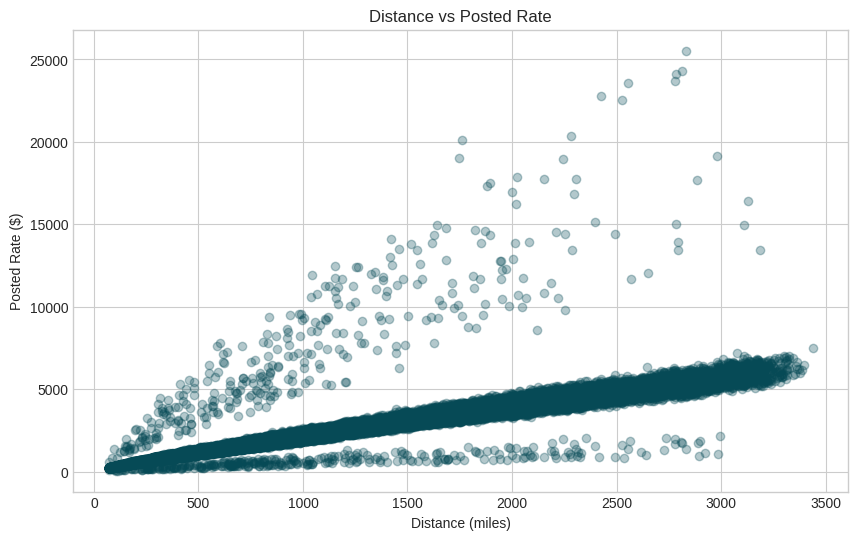

In [4]:
numeric_cols = df_train.select_dtypes(include=[np.number]).columns
correlations = df_train[numeric_cols].corr()['posted_rate'].sort_values(ascending=False)
print("Correlations with posted_rate:\n", correlations)

# Plotting distance vs posted_rate
plt.scatter(df_train['distance'], df_train['posted_rate'], alpha=0.3, color='#064A56')
plt.title('Distance vs Posted Rate')
plt.xlabel('Distance (miles)')
plt.ylabel('Posted Rate ($)')
plt.show()

## 5. Market Index and Day-of-Week Seasonality

The `market_index` feature has missing values and is completely missing from the December inputs. Let's see if there is a daily/weekly cycle in `market_index` that we can model with the day of the week.

Weekly market index mean:
    dayofweek_num  dayofweek  market_index
0              0     Monday      0.999586
1              1    Tuesday      1.075435
2              2  Wednesday      1.153226
3              3   Thursday      1.178978
4              4     Friday      1.134310
5              5   Saturday      1.047481
6              6     Sunday      0.988633


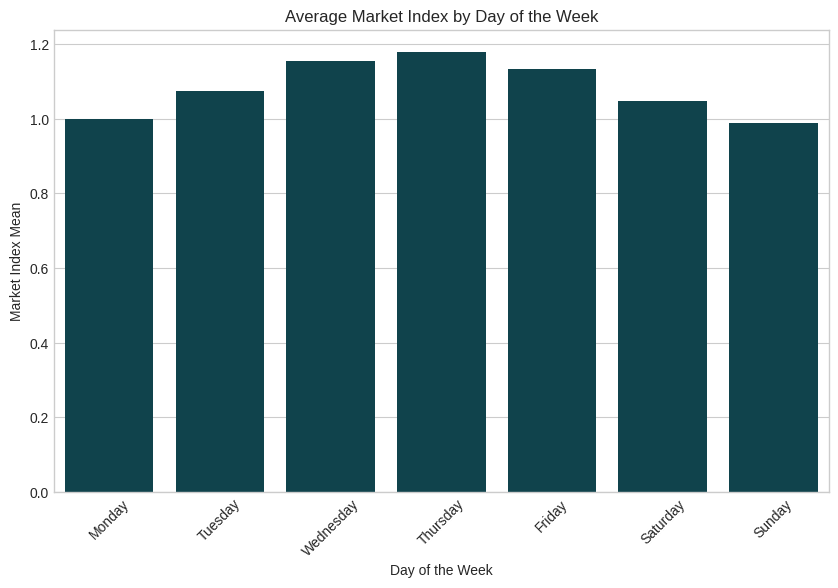

In [5]:
df_train['date'] = pd.to_datetime(df_train['date'])
df_train['dayofweek'] = df_train['date'].dt.day_name()
df_train['dayofweek_num'] = df_train['date'].dt.dayofweek

# Check average market_index by day of the week
weekly_market = df_train.groupby(['dayofweek_num', 'dayofweek'])['market_index'].mean().reset_index()
print("Weekly market index mean:\n", weekly_market)

# Plot weekly pattern
sns.barplot(data=weekly_market, x='dayofweek', y='market_index', color='#064A56')
plt.title('Average Market Index by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Market Index Mean')
plt.xticks(rotation=45)
plt.show()

## 6. Deep Dive: The Quote Signal Anomaly

Let's check the relationship between the actual rate per mile (`posted_rate / distance`) and the `quote_signal` column across different months. We will see that this feature is perturbed across time.

In [6]:
df_train['month'] = df_train['date'].dt.month
df_train['rate_per_mile'] = df_train['posted_rate'] / df_train['distance']

# We check correlation between rate_per_mile and quote_signal month-by-month
for m in sorted(df_train['month'].unique()):
    sub = df_train[df_train['month'] == m]
    corr = sub['rate_per_mile'].corr(sub['quote_signal'])
    print(f"Month {m:02d}: Correlation between Rate Per Mile and Quote Signal = {corr:.4f}")
    
    # Print first few samples to see the values
    if m in [1, 4, 8]:
        print(f"  First 3 rows of Month {m}:")
        for idx, row in sub.head(3).iterrows():
            print(f"    Rate/mile: {row['rate_per_mile']:.3f} | Quote signal: {row['quote_signal']:.3f} | Sum: {row['rate_per_mile']+row['quote_signal']:.3f}")

Month 01: Correlation between Rate Per Mile and Quote Signal = 0.4467
  First 3 rows of Month 1:
    Rate/mile: 2.353 | Quote signal: 2.396 | Sum: 4.749
    Rate/mile: 2.424 | Quote signal: 2.434 | Sum: 4.858
    Rate/mile: 1.863 | Quote signal: 1.845 | Sum: 3.707
Month 02: Correlation between Rate Per Mile and Quote Signal = 0.4790
Month 03: Correlation between Rate Per Mile and Quote Signal = 0.4858
Month 04: Correlation between Rate Per Mile and Quote Signal = -0.4717
  First 3 rows of Month 4:
    Rate/mile: 2.887 | Quote signal: 1.262 | Sum: 4.149
    Rate/mile: 2.124 | Quote signal: 2.032 | Sum: 4.155
    Rate/mile: 2.030 | Quote signal: 2.092 | Sum: 4.122
Month 05: Correlation between Rate Per Mile and Quote Signal = -0.4592
Month 06: Correlation between Rate Per Mile and Quote Signal = 0.4766
Month 07: Correlation between Rate Per Mile and Quote Signal = -0.4683
Month 08: Correlation between Rate Per Mile and Quote Signal = -0.0136
  First 3 rows of Month 8:
    Rate/mile: 2.36

### Understanding the Anomaly:
- In Months 1, 2, 3, 6, 9: `rate_per_mile` matches `quote_signal` directly.
- In Months 4, 5, 7, 10: `rate_per_mile` matches `4.15 - quote_signal` (inverted).
- In Month 8: It is a 50-50 mixture of direct and inverted values.
- In validation set (Months 11 and 12), the correlation drops to zero, which implies a similar mixed/perturbed blend.
- Crucially, `quote_signal` is completely missing in `december-chart-inputs.csv`.

**Conclusion:** We should exclude `quote_signal` from our final model to ensure it generalizes properly to the validation and December test data.

## 7. Rates by Equipment Type

Let's see if the rate per mile differs by equipment type (Dry Van, Flatbed, Reefer).

             count      mean       std       min       25%       50%  \
equipment                                                              
Dry Van    27202.0  2.115401  0.538102  0.333709  1.920572  2.046203   
Flatbed     8753.0  2.294729  0.610187  0.353881  2.076055  2.219683   
Reefer     12045.0  2.383376  0.615467  0.386292  2.167801  2.311540   

                75%        max  
equipment                       
Dry Van    2.211423  12.816710  
Flatbed    2.407007  12.949578  
Reefer     2.494937  14.125294  


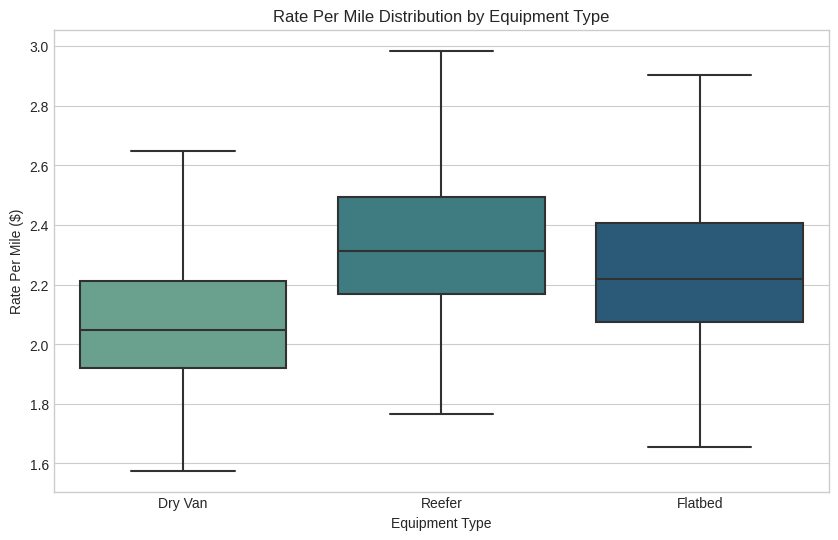

In [7]:
equipment_stats = df_train.groupby('equipment')['rate_per_mile'].describe()
print(equipment_stats)

# Plot rate per mile distributions
sns.boxplot(data=df_train, x='equipment', y='rate_per_mile', showfliers=False, palette='crest')
plt.title('Rate Per Mile Distribution by Equipment Type')
plt.xlabel('Equipment Type')
plt.ylabel('Rate Per Mile ($)')
plt.show()

## 8. Lexington and Fort Wayne Coordinate Extraction

Let's verify that we can reliably retrieve unique coordinate mappings for the December route (Lexington to Fort Wayne) from the training dataset.

In [8]:
lex_coords = df_train[df_train['pickup'] == 'Lexington'][['pickup_lat', 'pickup_lon']].drop_duplicates()
fw_coords = df_train[df_train['delivery'] == 'Fort Wayne'][['delivery_lat', 'delivery_lon']].drop_duplicates()

print("Lexington pickup coordinates in training:")
print(lex_coords)

print("\nFort Wayne delivery coordinates in training:")
print(fw_coords)

assert len(lex_coords) == 1, "Lexington has non-unique coordinates!"
assert len(fw_coords) == 1, "Fort Wayne has non-unique coordinates!"
print("\nCoordinates verified as constant and unique. We can safely impute them for December inputs.")

Lexington pickup coordinates in training:
    pickup_lat  pickup_lon
28    36.99152   -84.99876

Fort Wayne delivery coordinates in training:
    delivery_lat  delivery_lon
24      41.31561     -85.36206

Coordinates verified as constant and unique. We can safely impute them for December inputs.


## 9. Model Validation Split Strategy

To ensure our model generalizes well to future periods (since the validation dataset is from November and December), we design two validation strategies:
1. **Random 80/20 Train-Test Split:** A baseline to evaluate standard cross-sectional performance.
2. **Time-Based Validation Split (Train on Months 1-9, Validate on Month 10):** This mimics the real-world scenario of training on past data to forecast future load rates (Month 10).

In [9]:
from sklearn.model_selection import train_test_split

# Preprocessing dates to determine splits
df_train['date'] = pd.to_datetime(df_train['date'])
df_train['month'] = df_train['date'].dt.month

# 1. Random 80/20 Split
train_random, val_random = train_test_split(df_train, test_size=0.2, random_state=42)
print(f"Random Split - Train size: {len(train_random)}, Validation size: {len(val_random)}")

# 2. Time-Based Split (Train on Months 1-9, Validate on Month 10)
train_time = df_train[df_train['month'] < 10]
val_time = df_train[df_train['month'] == 10]
print(f"Time-based Split - Train size (Months 1-9): {len(train_time)}, Validation size (Month 10): {len(val_time)}")

Random Split - Train size: 38400, Validation size: 9600
Time-based Split - Train size (Months 1-9): 43147, Validation size (Month 10): 4853


## 10. Conclusions for Model Architecture

1. **Drop `quote_signal`:** Since `quote_signal` is missing from the December predictions and synthetically perturbed/mixed in other months, using it directly will lead to incorrect predictions.
2. **Use Date Features:** Since `market_index` follows a very strong weekly seasonality, we will extract `dayofweek`, `month`, and `day` features so the model can capture these fluctuations.
3. **Use Tree-based Gradient Boosting:** We will train `HistGradientBoostingRegressor` on the base features (distance, weight, coordinates, equipment, date features) to yield a highly robust, outlier-resistant model.